# Wyżarzacze kwantowe

Wyżarzaczem kwantowym nazywamy maszynę, która fizycznie implementuje algorytm wyżarzania kwantowego. Obecnie najpopularniejsze są urządzenia produkowane przez firmę DWave. W sercu każdej maszyny leży procesor kwantowy, *Quantum Proccesing Unit* (QPU), składający się z kubitów połączonych couplerami (czasami słowo *coupler* tłumaczy się jako "sprzęgacz"). W tym szkoleniu nie będziemy wdawać się w szczegóły jak te kubity i couplery fizycznie wyglądają. Strukturę połączeń między kubitami w QPU nazywamy **topologią**.  

## Topologie procesorów DWave
### Chimera

Jest to pierwsza i najstarsza z istniejących topologii. Składa się z komórek jednostkowych (ang. *Unit Cell*) połączonych ze sobą w kształt kraty. Każda z komórek składa się z ośmiu kubitów połączonych ze sobą jak pełny graf dwudzielny $K_{4, 4}$. Poniżej jest przedstawiony przykład Chimery **C2**

<img src="../pliki_pomocnicze/pictures/chimera.png" width="700" height="700" />

### Pegasus

Jest to obecnie standardowa topologia używana w wyżarzaczach D-Wave. Nie ma najprostrzej konstrukcji.

![image](../pliki_pomocnicze/pictures/pegasus.png)

### Zephyr

Najnowocześniejsza topologia. Urządzenia które ją implementują są obecnie w fazie prototypów. **Z2** czyli zephyr złorzony z 2x2 komórek jednostkowych. Na pierwszy rzut oka widać zarówno więcej kubitów jak i znacznie gęściejszą siatkę połączeń.


![image](../pliki_pomocnicze/pictures/zephyr.png)

## Embedding

Z powodu tego jak jest skonstuowana sieć połączeń w QPU, wiele problemów trzeba osadzić. Powoduje to utworzenie tzw. *łańcuchów*. Oznacza to, że jeden qubit logiczny (zmienna) jest reprezentowany przez kilka qubitów fizycznych połączonych w łańcuch. Każdy z nich powinien mieć ten sam spin. Gdy tak się nie dzieje mówimy o *łamaniu łańcucha*.


Znaleziono osadzenie:
  K3 wierzchołek 0 -> wierzchołek 3
  K3 wierzchołek 1 -> wierzchołek 5
  K3 wierzchołek 2 -> łańcuch [1, 4]


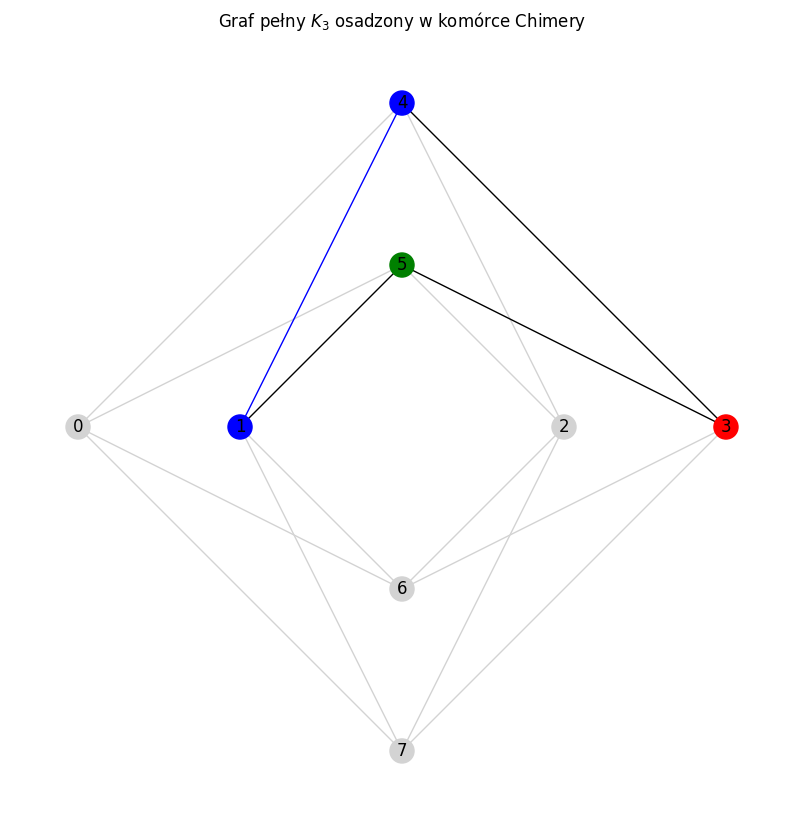

In [1]:
import networkx as nx
import dwave_networkx as dnx
import minorminer
import matplotlib.pyplot as plt


chimera = dnx.chimera_graph(1, 1, 4)  # pojedyńcza komórka chimery
K3 = nx.complete_graph(3)

# Automatyczne szukanie osadzenia
embedding = minorminer.find_embedding(K3, chimera)
print("Znaleziono osadzenie:")
for k3_node, chain in embedding.items():
    if len(chain) > 1:
        print(f"  K3 wierzchołek {k3_node} -> łańcuch {chain}")
    else:
        print(f"  K3 wierzchołek {k3_node} -> wierzchołek {chain[0]}")



chain_colors = {k: color for k, color in zip(embedding.keys(), ["red", "green", "blue", "purple"])}

# Budujemy mapę kolorów dla komórki chimery
node_color = {}
edge_color = {}

for k3_node, chain in embedding.items():
    for q in chain:
        node_color[q] = chain_colors[k3_node]
    if len(chain) > 1:
        v, w = chain
        edge_color[(v, w)] = chain_colors[k3_node]
        edge_color[(w, v)] = chain_colors[k3_node]

for (v, w) in K3.edges():
    x = embedding[v]
    y = embedding[w]
    if len(x) == len(y) == 1:
        edge_color[(x[0], y[0])] = "black"
        edge_color[(y[0], x[0])] = "black"
    elif len(x) > 1:
        edge_color[(x[0], y[0])] = "black"
        edge_color[(y[0], x[0])] = "black"
        edge_color[(x[1], y[0])] = "black"
        edge_color[(y[0], x[1])] = "black"
    else:
        edge_color[(x[0], y[0])] = "black"
        edge_color[(y[0], x[0])] = "black"
        edge_color[(x[0], y[1])] = "black"
        edge_color[(y[1], x[0])] = "black"
    
# TODO: napisz lepiej
    
    


# Kolor dla kubitów i krawędzi nie używanych w embeddingu
default_color = "lightgray"

node_colors = [node_color.get(node, default_color) for node in chimera.nodes()]
edge_colors = [edge_color.get(edge, default_color) for edge in chimera.edges()]


plt.figure(figsize=(8, 8))
dnx.draw_chimera(chimera, node_color=node_colors, edge_color=edge_colors, with_labels=True, node_size=300)
plt.title(rf"Graf pełny $K_3$ osadzony w komórce Chimery")
plt.show()

w powyższym obrazku czarne krawędzie oznaczają krawędzie w oryginalnym grafiem a krawędzie w kolorze wierzchołków oznaczają łańcuch.

### Większy przykład na prawdziwej architekturze
Najpierw trzeba klikną "Source - QPU", a następnie po lewej stronie "show chains" oraz "show broken chains

In [ ]:
# dokładnie co się dzieje w kodzie będzie opisane później
# niezbędy token by móc się połączyć
with open("token.txt", "r") as f:
    token = f.read()

#Zdefiniowanie maszyny której będziemy używać
from dwave.system import DWaveSampler, AutoEmbeddingComposite
import dwave.inspector
import networkx as nx


sampler = DWaveSampler(token=token, solver="Advantage_system4.1")
graph = nx.complete_graph(50)
h = {node: 0.5 for node in graph.nodes}
J = {edge: 1 for edge in graph.edges}

# automatycznie mapujemy nasz problem na QPU
solver = AutoEmbeddingComposite(sampler)

# Rozwiązujemy problem
solution = solver.sample_ising(h, J)
dwave.inspector.show(solution)